# ============================================================
# EXDARK DATA PREPROCESSING
# ============================================================
#
# During preprocessing, we prepared the ExDark dataset for
# YOLO object detection while preserving the original images.
#
# 1. DATASET ORGANIZATION
#    - Organized the dataset into three splits:
#        train/  -> 5,147 images
#        valid/  -> 1,099 images
#        test/   -> 1,116 images
#    - Ensured that every image had a corresponding YOLO
#      annotation (.txt) file.
#    - Final dataset: 7,362 valid image-label pairs.
#
# 2. ANNOTATION FORMAT
#    - Used YOLO-format bounding-box annotations:
#        class_id, x_center, y_center, width, height
#    - Coordinates were represented as normalized values
#      between 0 and 1.
#
# 3. ANNOTATION VALIDATION
#    - Checked that annotation files existed for all images.
#    - Checked that every label contained valid bounding-box
#      information.
#    - Verified that class IDs were within the 12 ExDark classes.
#    - Verified that bounding-box coordinates were valid.
#
# 4. CLASS DEFINITIONS
#    - The dataset contains 12 object classes:
#      Bicycle, Boat, Bottle, Bus, Car, Cat, Chair, Cup,
#      Dog, Motorbike, People, Table.
#
# 5. DATASET CONFIGURATION
#    - Created/verified data.yaml containing:
#        * dataset path
#        * training image path
#        * validation image path
#        * test image path
#        * number of classes
#        * class names
#
# 6. TRAINING PREPARATION
#    - The dataset was copied from Google Drive to Colab's
#      local storage to reduce the I/O bottleneck caused by
#      reading thousands of images directly from Google Drive.
#    - Images were resized to 640x640 during YOLO training.
#    - YOLO automatically handled the required image
#      normalization and augmentation during training.
#
# 7. DATA LEAKAGE PREVENTION
#    - Training, validation, and test images were kept in
#      separate folders.
#    - The test set was not used for model training.
#
# The final dataset was therefore ready for training and
# evaluating YOLO11s and YOLO26s under the same conditions.
# ============================================================

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

DATASET_PATH = "/content/drive/MyDrive/ExDark_YOLO"

print("Dataset contents:")
for item in os.listdir(DATASET_PATH):
    print(item)

Dataset contents:
test
runs
train
valid
data.yaml


In [3]:
DATASET_PATH = "/content/drive/MyDrive/ExDark_YOLO"

with open(f"{DATASET_PATH}/data.yaml", "r") as f:
    print(f.read())

path: /content/drive/MyDrive/ExDark_YOLO
train: train/images
val: valid/images
test: test/images

nc: 12

names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Car
  5: Cat
  6: Chair
  7: Cup
  8: Dog
  9: Motorbike
  10: People
  11: Table



In [4]:
DATASET_PATH = "/content/drive/MyDrive/ExDark_YOLO"

yaml_content = """path: /content/drive/MyDrive/ExDark_YOLO
train: train/images
val: valid/images
test: test/images

nc: 12

names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Car
  5: Cat
  6: Chair
  7: Cup
  8: Dog
  9: Motorbike
  10: People
  11: Table
"""

with open(f"{DATASET_PATH}/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml updated successfully.")

data.yaml updated successfully.


In [5]:
print(open(f"{DATASET_PATH}/data.yaml").read())

path: /content/drive/MyDrive/ExDark_YOLO
train: train/images
val: valid/images
test: test/images

nc: 12

names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Car
  5: Cat
  6: Chair
  7: Cup
  8: Dog
  9: Motorbike
  10: People
  11: Table



In [6]:
import os

DATASET_PATH = "/content/drive/MyDrive/ExDark_YOLO"

for split in ["train", "valid", "test"]:
    images_path = os.path.join(DATASET_PATH, split, "images")
    labels_path = os.path.join(DATASET_PATH, split, "labels")

    images = [f for f in os.listdir(images_path)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    labels = [f for f in os.listdir(labels_path)
              if f.endswith(".txt")]

    print(f"{split}:")
    print(f"  Images: {len(images)}")
    print(f"  Labels: {len(labels)}")

train:
  Images: 5147
  Labels: 5147
valid:
  Images: 1099
  Labels: 1099
test:
  Images: 1116
  Labels: 1116


In [9]:
import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [7]:
%pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.4 MB/s eta 0:00:00


In [11]:
!cp -r "/content/drive/MyDrive/ExDark_YOLO" "/content/"

In [12]:
import ultralytics
from ultralytics import YOLO
import torch
import os

# --------------------------------------------------
# EXDARK YOLO BASELINE EXPERIMENT
# --------------------------------------------------

DATASET_PATH = "/content/ExDark_YOLO"
DATA_YAML = f"{DATASET_PATH}/data.yaml"

# Model
MODEL_NAME = "yolo11s.pt"

# Training configuration
EPOCHS = 10
IMG_SIZE = 640
BATCH_SIZE = 16

# Device
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("========================================")
print("ExDark YOLO Training Configuration")
print("========================================")
print(f"Model:       {MODEL_NAME}")
print(f"Epochs:      {EPOCHS}")
print(f"Batch size:  {BATCH_SIZE}")
print(f"Image size:  {IMG_SIZE}")
print(f"Device:      {DEVICE}")
print(f"GPU:         {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("========================================")

model = YOLO(MODEL_NAME)

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=f"{DATASET_PATH}/runs",
    name="exdark_yolo11s_10epochs",
    exist_ok=True,
    pretrained=True,
    verbose=True
)

ExDark YOLO Training Configuration
Model:       yolo11s.pt
Epochs:      10
Batch size:  16
Image size:  640
Device:      0
GPU:         Tesla T4
Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ExDark_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_d

In [13]:
RUN_DIR = "/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs"

print("Training files:")
for item in os.listdir(RUN_DIR):
    print(item)

Training files:
train_batch0.jpg
val_batch1_pred.jpg
val_batch1_labels.jpg
val_batch2_pred.jpg
confusion_matrix.png
labels.jpg
val_batch2_labels.jpg
confusion_matrix_normalized.png
train_batch2.jpg
results.csv
train_batch1.jpg
BoxPR_curve.png
weights
val_batch0_pred.jpg
results.png
val_batch0_labels.jpg
BoxR_curve.png
BoxP_curve.png
BoxF1_curve.png
args.yaml


In [14]:

MODEL_PATH = "/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs/weights/best.pt"
DATA_YAML = "/content/ExDark_YOLO/data.yaml"

model = YOLO(MODEL_PATH)

test_results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,417,444 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 166.4±112.4 MB/s, size: 218.9 KB)
val: Scanning /content/drive/MyDrive/ExDark_YOLO/test/labels... 1116 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1116/1116 151.4it/s 7.4s
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_02636.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_02637.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_03363.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_04723.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_06683.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_06686.jpg: corrupt JPEG restored and saved
va

In [15]:
print("Precision:", test_results.box.mp)
print("Recall:", test_results.box.mr)
print("mAP@50:", test_results.box.map50)
print("mAP@50:95:", test_results.box.map)

Precision: 0.7937277351299512
Recall: 0.6468586928196626
mAP@50: 0.7547766559587058
mAP@50:95: 0.49826202790253155


In [16]:
import os
import random

TEST_IMAGES = "/content/ExDark_YOLO/test/images"

image_files = [
    f for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
selected_images = random.sample(image_files, min(10, len(image_files)))

print("Selected test images:")
for image in selected_images:
    print(image)

Selected test images:
2015_06214.png
2015_03146.jpg
2015_05334.JPEG
2015_03068.jpg
2015_06506.jpg
2015_05174.jpg
2015_06281.jpg
2015_02791.jpg
2015_04881.jpg
2015_00282.jpg


In [17]:
MODEL_PATH = "/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs/weights/best.pt"

model = YOLO(MODEL_PATH)

selected_paths = [
    os.path.join(TEST_IMAGES, image)
    for image in selected_images
]

results = model.predict(
    source=selected_paths,
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    project="/content/ExDark_YOLO/runs",
    name="test_images_predictions",
    exist_ok=True
)


0: 640x640 3 Motorbikes, 3 Peoples, 11.5ms
1: 640x640 (no detections), 11.5ms
2: 640x640 1 Chair, 1 Dog, 2 Tables, 11.5ms
3: 640x640 1 Cat, 11.5ms
4: 640x640 4 Peoples, 11.5ms
5: 640x640 1 Dog, 11.5ms
6: 640x640 4 Peoples, 11.5ms
7: 640x640 1 Car, 11.5ms
8: 640x640 1 Cup, 11.5ms
9: 640x640 1 Bicycle, 1 People, 11.5ms
Speed: 3.0ms preprocess, 11.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/ExDark_YOLO/runs/test_images_predictions



2015_03146.jpg


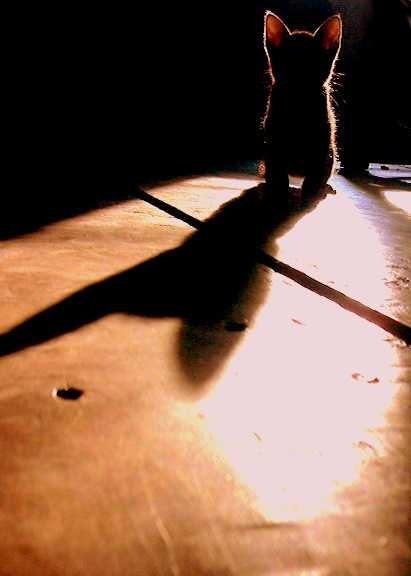


2015_03068.jpg


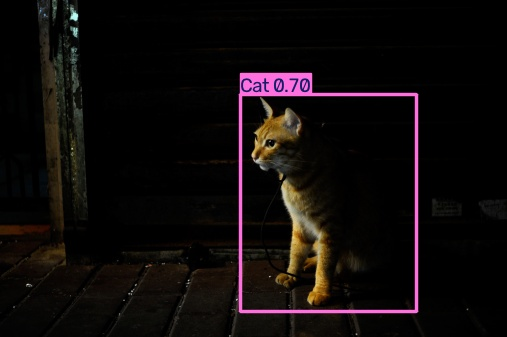


2015_06506.jpg


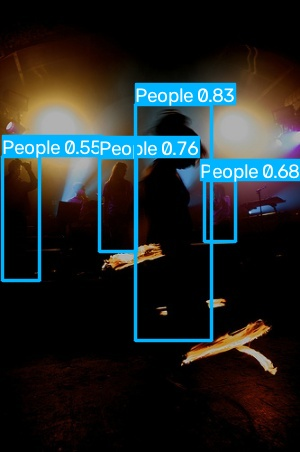


2015_05174.jpg


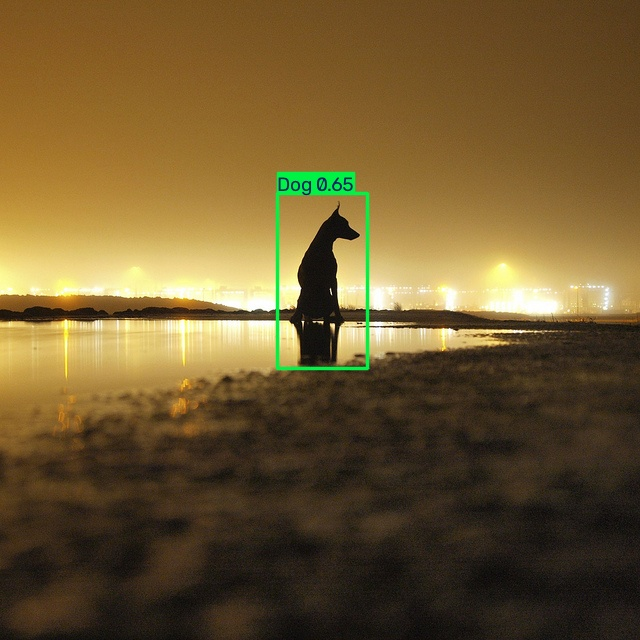


2015_06281.jpg


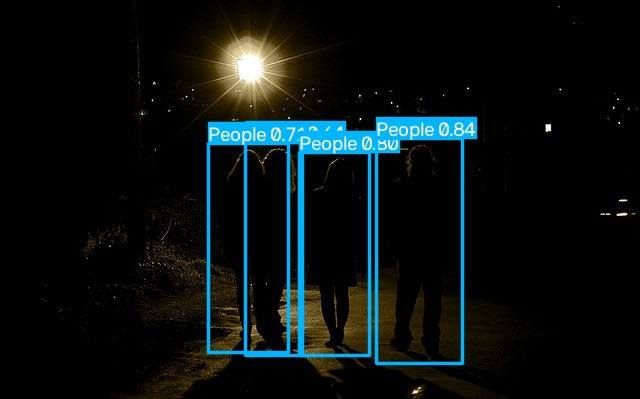


2015_02791.jpg


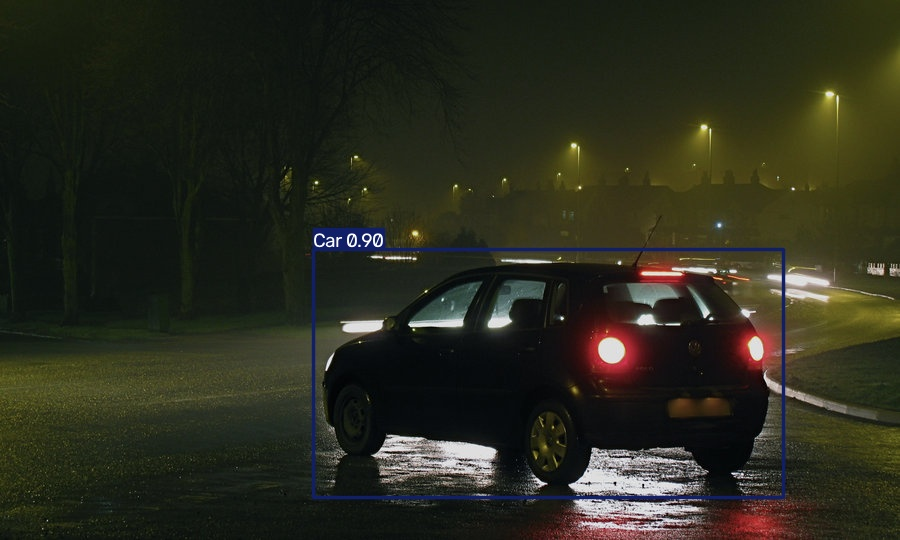


2015_04881.jpg


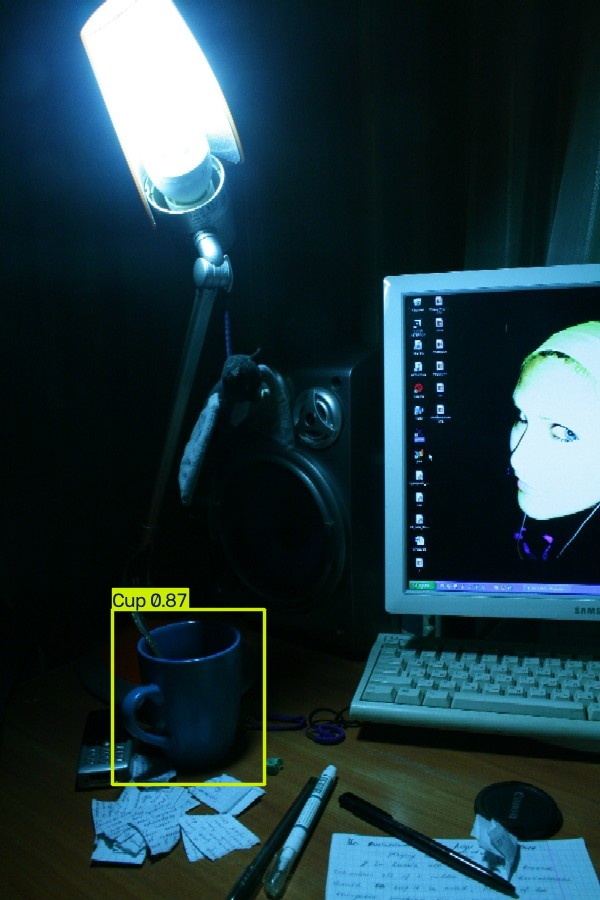


2015_00282.jpg


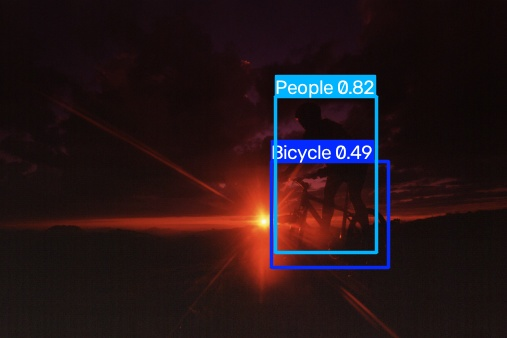

In [18]:
from IPython.display import display, Image

OUTPUT_DIR = "/content/ExDark_YOLO/runs/test_images_predictions"

for image in selected_images:
    output_path = os.path.join(OUTPUT_DIR, image)

    if os.path.exists(output_path):
        print(f"\n{image}")
        display(Image(filename=output_path))

In [19]:
!pip install -q gradio

In [20]:
import time

MODEL_PATH = "/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs/weights/best.pt"

model = YOLO(MODEL_PATH)

TEST_IMAGES = "/content/ExDark_YOLO/test/images"

image_files = [
    os.path.join(TEST_IMAGES, f)
    for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Use a small fixed sample
image_files = image_files[:50]

start = time.time()

for image in image_files:
    model.predict(
        source=image,
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )

elapsed = time.time() - start

print(f"Images processed: {len(image_files)}")
print(f"Total time: {elapsed:.2f} seconds")
print(f"Average time/image: {elapsed/len(image_files):.4f} seconds")
print(f"Approximate FPS: {len(image_files)/elapsed:.2f}")

Images processed: 50
Total time: 3.17 seconds
Average time/image: 0.0634 seconds
Approximate FPS: 15.77


In [22]:
import torch

DATA_YAML = "/content/ExDark_YOLO/data.yaml"

model2 = YOLO("yolo26s.pt")

results2 = model.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/ExDark_YOLO/runs",
    name="exdark_yolo26s_10epochs",
    exist_ok=True,
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ExDark_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0

In [23]:
MODEL_PATH = "/content/ExDark_YOLO/runs/exdark_yolo26s_10epochs/weights/best.pt"
DATA_YAML = "/content/ExDark_YOLO/data.yaml"

model = YOLO(MODEL_PATH)

test_results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,417,444 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 58.5±35.0 MB/s, size: 218.9 KB)
val: Scanning /content/drive/MyDrive/ExDark_YOLO/test/labels.cache... 1116 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1116/1116 246.4Mit/s 0.0s
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_02636.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_02637.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_03363.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_04723.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_06683.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_06686.jpg: corrupt JPEG restored and sav

In [24]:
print("========================================")
print("YOLO26s TEST METRICS")
print("========================================")

print(f"Precision     : {test_results.box.mp:.4f}")
print(f"Recall        : {test_results.box.mr:.4f}")
print(f"mAP@50        : {test_results.box.map50:.4f}")
print(f"mAP@50:95     : {test_results.box.map:.4f}")

YOLO26s TEST METRICS
Precision     : 0.7689
Recall        : 0.6706
mAP@50        : 0.7502
mAP@50:95     : 0.4931


Testing new data with the 2 models

In [26]:
DATA_YAML = "/content/ExDark_YOLO/data.yaml"

results11 = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project="/content/ExDark_YOLO/runs",
    name="yolo11s_test_evaluation",
    exist_ok=True
)

results26 = model2.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project="/content/ExDark_YOLO/runs",
    name="yolo26s_test_evaluation",
    exist_ok=True
)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,417,444 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 134.9±147.7 MB/s, size: 237.5 KB)
val: Scanning /content/drive/MyDrive/ExDark_YOLO/test/labels.cache... 1116 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1116/1116 222.9Mit/s 0.0s
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_02636.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_02637.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_03363.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_04723.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_06683.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/ExDark_YOLO/test/images/2015_06686.jpg: corrupt JPEG restored and s

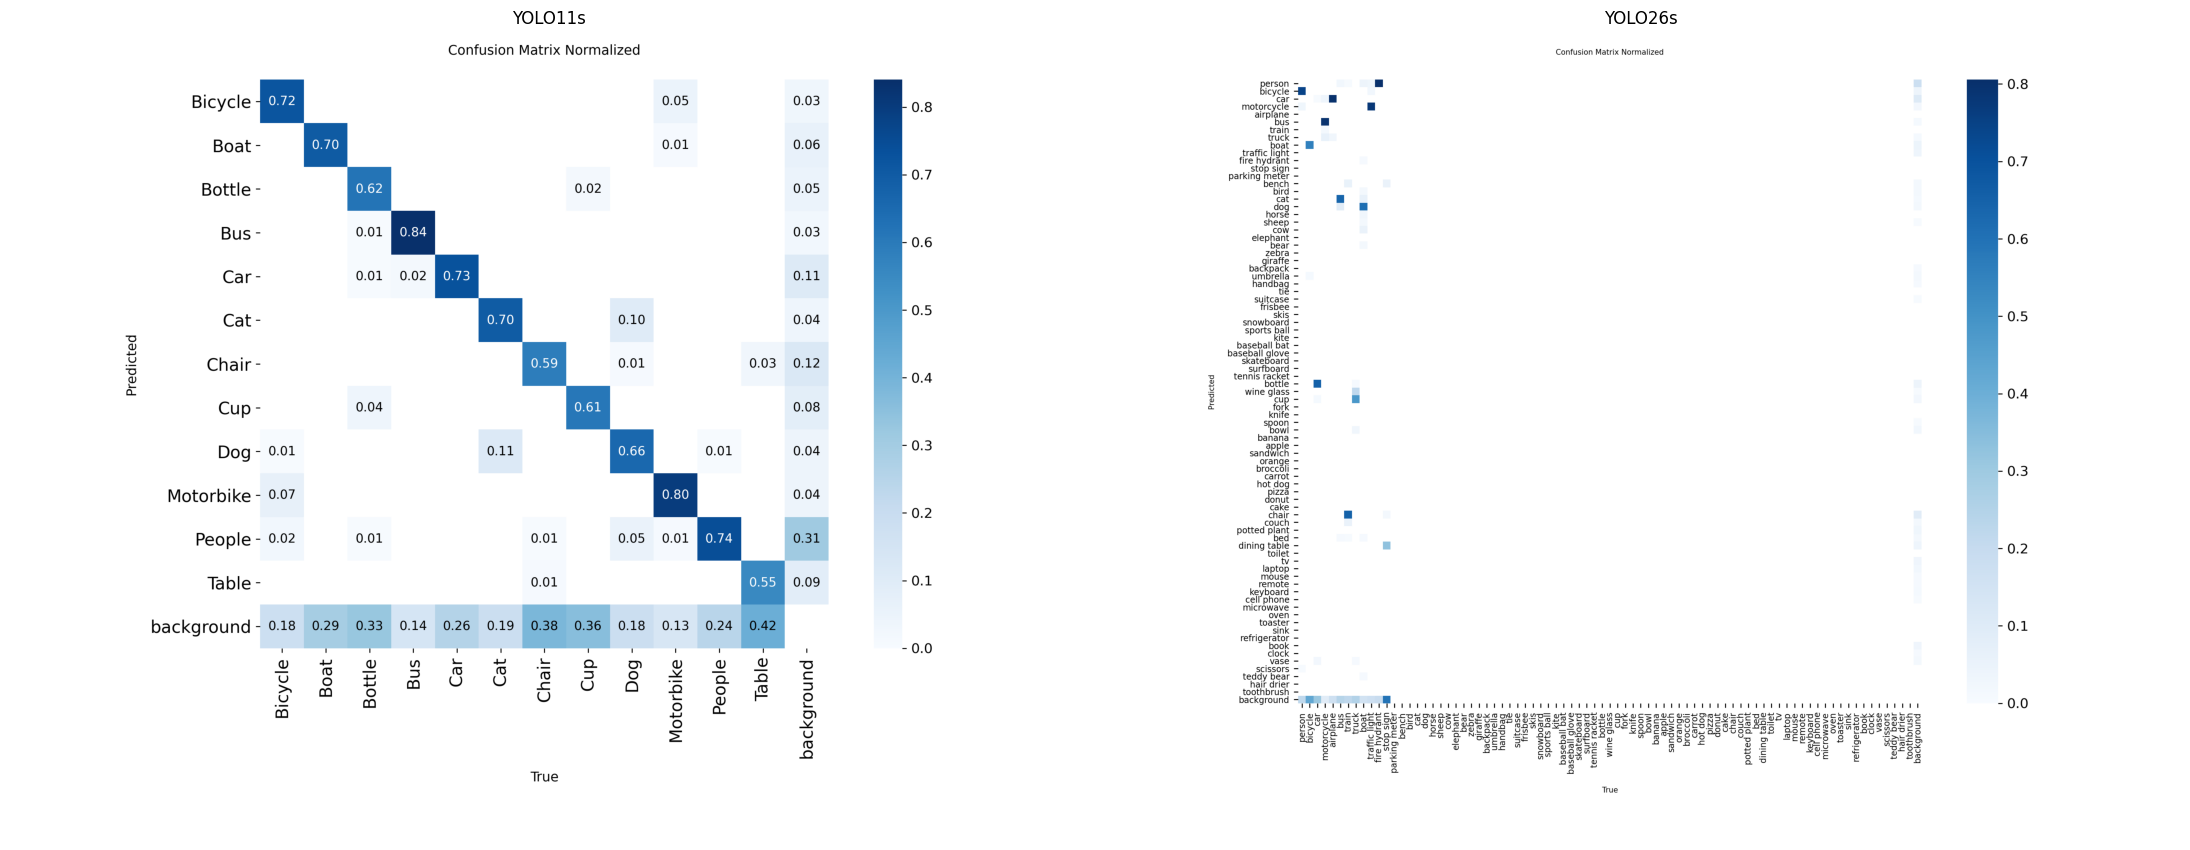

In [27]:
from PIL import Image
import matplotlib.pyplot as plt

cm11 = "/content/ExDark_YOLO/runs/yolo11s_test_evaluation/confusion_matrix_normalized.png"
cm26 = "/content/ExDark_YOLO/runs/yolo26s_test_evaluation/confusion_matrix_normalized.png"

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

axes[0].imshow(Image.open(cm11))
axes[0].set_title("YOLO11s")
axes[0].axis("off")

axes[1].imshow(Image.open(cm26))
axes[1].set_title("YOLO26s")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "mAP@50",
        "mAP@50:95"
    ],
    "YOLO11s": [
        results11.box.mp,
        results11.box.mr,
        results11.box.map50,
        results11.box.map
    ],
    "YOLO26s": [
        results26.box.mp,
        results26.box.mr,
        results26.box.map50,
        results26.box.map
    ]
})

metrics_df["Difference (YOLO26s - YOLO11s)"] = (
    metrics_df["YOLO26s"] - metrics_df["YOLO11s"]
)

metrics_df

,Metric,YOLO11s,YOLO26s,Difference (YOLO26s - YOLO11s)
0,Precision,0.768899,0.003342,-0.765557
1,Recall,0.670583,0.020944,-0.649639
2,mAP@50,0.750219,0.000158,-0.750061
3,mAP@50:95,0.493061,0.000052,-0.493009


In [29]:
import gradio as gr

# Load trained model
MODEL_PATH = "/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs/weights/best.pt"
model = YOLO(MODEL_PATH)

def detect_objects(image):
    results = model.predict(
        source=image,
        imgsz=640,
        conf=0.25,
        device=0
    )

    # Annotated image
    annotated_image = results[0].plot()

    return annotated_image

demo = gr.Interface(
    fn=detect_objects,
    inputs=gr.Image(type="numpy", label="Upload an image"),
    outputs=gr.Image(label="YOLO11s Predictions"),
    title="ExDark YOLO Object Detection",
    description="Upload an image to detect objects using the trained YOLO11s model."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0dfb747d9cf5f1d143.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
